# Logistic Regression in Python: A Step-by-Step Guide

Companion notebook for the blog post: [Logistic Regression in Python: A Step-by-Step Guide](https://cmdavis25.github.io/blog.html#blog_logistic_regression_2026-04-17.md)

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI ML Repository, id=601)  
**Task:** Binary classification — predict machine failure from sensor readings  
**Requires:** `ucimlrepo`, `pandas`, `numpy`, `scikit-learn`, `matplotlib`

Install dependencies if needed:
```
pip install ucimlrepo pandas numpy scikit-learn matplotlib
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

---
## Step 1 — Load the Dataset

In [2]:
# Fetch the AI4I 2020 Predictive Maintenance dataset from UCI ML Repository
dataset = fetch_ucirepo(id=601)

X_raw = dataset.data.features
y = dataset.data.targets["Machine failure"]

print("Feature matrix shape:", X_raw.shape)
print("Target shape:        ", y.shape)
print()
X_raw.head()

Feature matrix shape: (10000, 6)
Target shape:         (10000,)



,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [3]:
print(X_raw.dtypes)
print()
print("Target class distribution:")
print(y.value_counts())
print(f"\nFailure rate: {y.mean():.2%}")

Type                       str
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
dtype: object

Target class distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


---
## Step 2 — Preprocessing

### Check for Missing Values

In [4]:
print("Missing values per column:")
print(X_raw.isnull().sum())

Missing values per column:
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
dtype: int64


### Encode the Categorical Column

`Type` contains product quality levels: L (Low), M (Medium), H (High). We one-hot encode it with `drop_first=True` to avoid the dummy variable trap.

In [5]:
X_encoded = pd.get_dummies(X_raw, columns=["Type"], drop_first=True)
print("Columns after encoding:")
print(X_encoded.columns.tolist())
X_encoded.head()

Columns after encoding:
['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Type_L', 'Type_M']


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,True
1,298.2,308.7,1408,46.3,3,True,False
2,298.1,308.5,1498,49.4,5,True,False
3,298.2,308.6,1433,39.5,7,True,False
4,298.2,308.7,1408,40.0,9,True,False


### Scale the Features

`StandardScaler` transforms each feature to mean=0, std=1. This is important for logistic regression: it stabilizes gradient descent and makes coefficients directly comparable in magnitude.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (10000, 7)


---
## Step 3 — Separate Features and Target

In [7]:
X = X_scaled
y_arr = y.values

print("Feature matrix shape:", X.shape)
print("Target array shape:  ", y_arr.shape)

Feature matrix shape: (10000, 7)
Target array shape:   (10000,)


---
## Step 4 — Train/Test Split

80/20 split with `stratify=y` to preserve the class ratio in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_arr,
    test_size=0.2,
    random_state=42,
    stratify=y_arr
)

print(f"Training set:  {X_train.shape[0]} rows  ({y_train.mean():.2%} failures)")
print(f"Test set:      {X_test.shape[0]} rows  ({y_test.mean():.2%} failures)")

Training set:  8000 rows  (3.39% failures)
Test set:      2000 rows  (3.40% failures)


---
## Step 5 — Fit Logistic Regression and Make Predictions

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



---
## Step 6 — Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> **Note:** High accuracy on imbalanced data can be misleading. A model that always predicts 'No Failure' would achieve ~96.6% accuracy — without ever catching a single failure.

In [10]:
# Manual calculation
tp = ((y_pred == 1) & (y_test == 1)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()
total = len(y_test)
manual_accuracy = (tp + tn) / total

# sklearn
sklearn_accuracy = accuracy_score(y_test, y_pred)

print(f"Manual accuracy:  {manual_accuracy:.4f}")
print(f"sklearn accuracy: {sklearn_accuracy:.4f}")
print()
print(f"Baseline (always predict 0): {(y_test == 0).mean():.4f}")

Manual accuracy:  0.9675
sklearn accuracy: 0.9675

Baseline (always predict 0): 0.9660


---
## Step 7 — Confusion Matrix

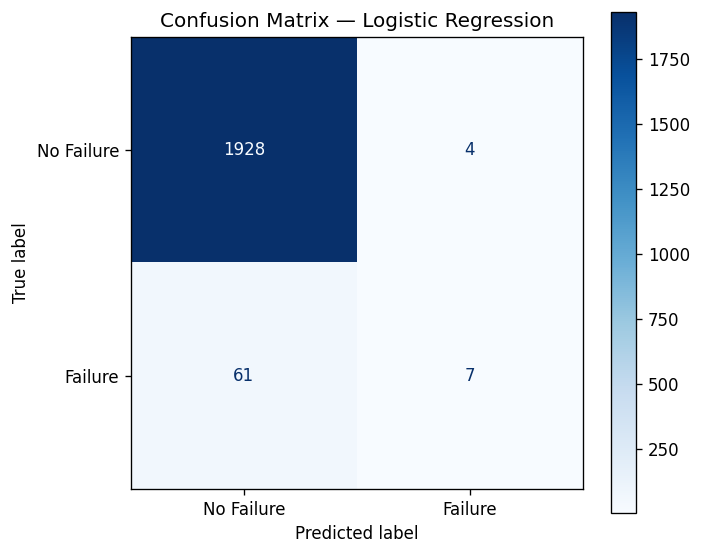

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Failure", "Failure"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("plots/logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

### Precision and Recall

Two metrics derived directly from the confusion matrix:

**Precision** — of all predicted failures, how many were actual failures?

$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall (Sensitivity)** — of all actual failures, how many did the model catch?

$$\text{Recall} = \frac{TP}{TP + FN}$$

For predictive maintenance, a missed failure (low recall) is typically worse than a false alarm (low precision).

In [12]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

# Manual equivalents from confusion matrix counts
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

manual_precision = tp / (tp + fp)
manual_recall    = tp / (tp + fn)

print(f"Precision — sklearn: {precision:.4f}  |  manual: {manual_precision:.4f}")
print(f"Recall    — sklearn: {recall:.4f}  |  manual: {manual_recall:.4f}")

Precision — sklearn: 0.6364  |  manual: 0.6364
Recall    — sklearn: 0.1029  |  manual: 0.1029


---
## Step 8 — ROC Curve and AUC

The ROC curve sweeps all decision thresholds and plots True Positive Rate vs. False Positive Rate. AUC (Area Under the Curve) summarizes the overall quality of the model's probability rankings:
- **0.5** = random guessing (red dashed baseline)
- **1.0** = perfect separation

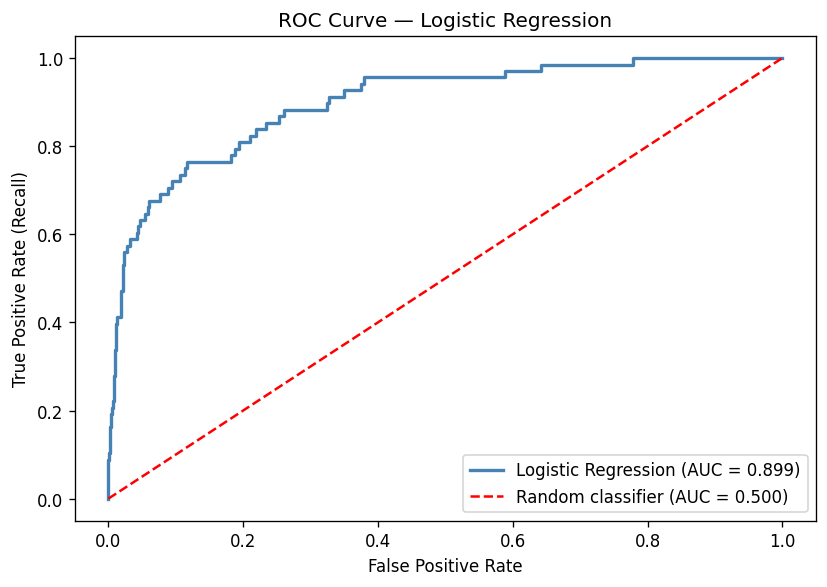

AUC Score: 0.8994


In [13]:
# Use predicted probabilities (not hard predictions) for the ROC curve
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"Logistic Regression (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="red", linestyle="--", lw=1.5,
        label="Random classifier (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Logistic Regression")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots/logistic_regression_roc_curve.png", dpi=150)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

---
## Step 9 — Coefficient Interpretation

Because features are scaled, coefficients are directly comparable. A positive coefficient means that feature increases the log-odds of failure; a negative coefficient means it decreases them.

In [14]:
feature_names = X_encoded.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", key=abs, ascending=False)

print(coef_df.to_string(index=False))

            Feature  Coefficient
             Torque     2.703138
   Rotational speed     1.998704
    Air temperature     1.433143
Process temperature    -0.968235
          Tool wear     0.787077
             Type_L     0.335154
             Type_M     0.092765


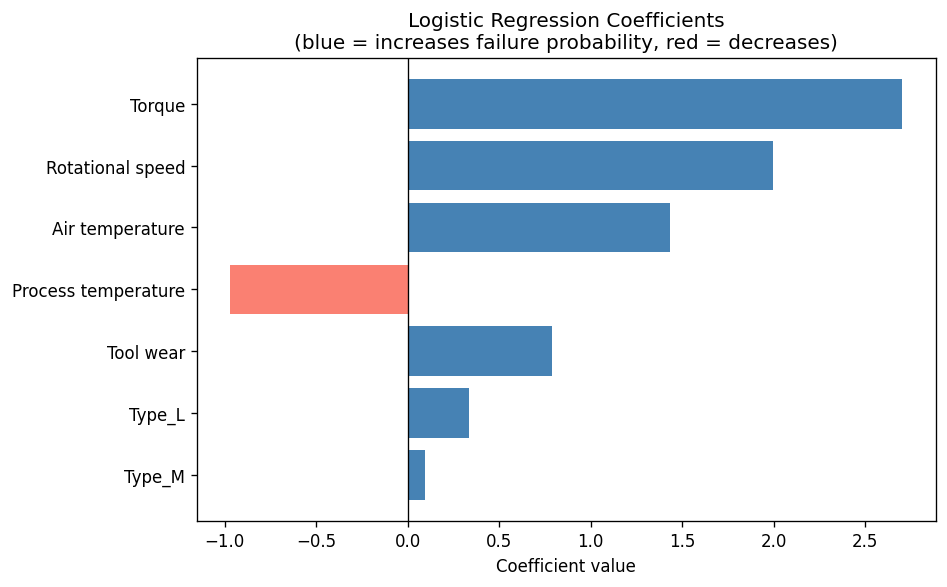

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue" if c > 0 else "salmon" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient value")
ax.set_title("Logistic Regression Coefficients\n"
             "(blue = increases failure probability, red = decreases)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("plots/logistic_regression_coefficients.png", dpi=150)
plt.show()

---
## Step 10 — Addressing Class Imbalance with Balanced Weights

With only ~3.4% failures, the default model learns that predicting "no failure" almost always pays off — leading to recall of just ~10%. `class_weight='balanced'` corrects this by weighting each class inversely proportional to its frequency, penalising missed failures more heavily during training.

In [16]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("=== Default weights ===")
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

print("=== class_weight='balanced' ===")
print(classification_report(y_test, y_pred_balanced, target_names=["No Failure", "Failure"]))

prec_default = precision_score(y_test, y_pred)
rec_default  = recall_score(y_test, y_pred)
prec_bal     = precision_score(y_test, y_pred_balanced)
rec_bal      = recall_score(y_test, y_pred_balanced)

print(f"{'':20s} {'Default':>10s}  {'Balanced':>10s}")
print(f"{'Precision':20s} {prec_default:>10.4f}  {prec_bal:>10.4f}")
print(f"{'Recall':20s} {rec_default:>10.4f}  {rec_bal:>10.4f}")

=== Default weights ===
              precision    recall  f1-score   support

  No Failure       0.97      1.00      0.98      1932
     Failure       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000

=== class_weight='balanced' ===
              precision    recall  f1-score   support

  No Failure       0.99      0.83      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000

                        Default    Balanced
Precision                0.6364      0.1421
Recall                   0.1029      0.8235


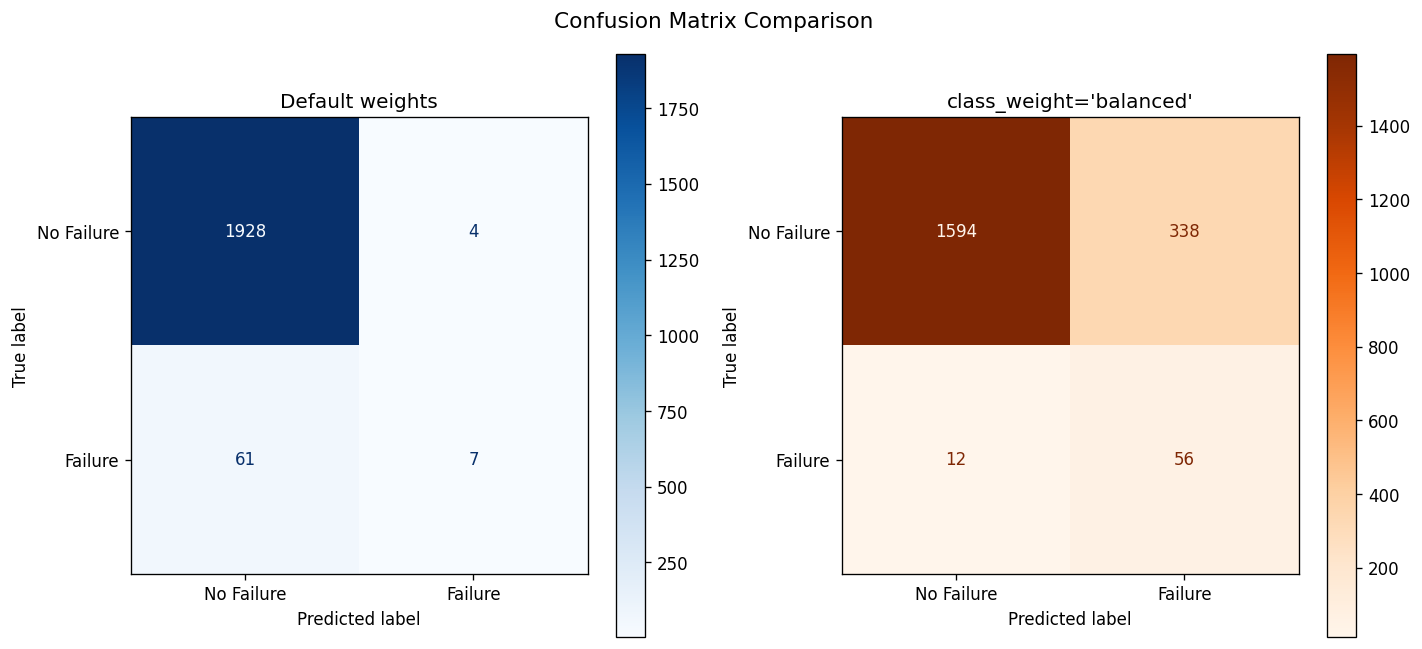

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Failure", "Failure"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Default weights")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_balanced,
    display_labels=["No Failure", "Failure"],
    cmap="Oranges", ax=axes[1]
)
axes[1].set_title("class_weight='balanced'")

plt.suptitle("Confusion Matrix Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("plots/logistic_regression_balanced_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---

**Next steps to explore:**
- Adjust the decision threshold using `predict_proba` to trade precision for recall
- Compare against a dummy baseline classifier with `sklearn.dummy.DummyClassifier`